# MLP

In [433]:
import torch 
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt 
from IPython.display import Image
%matplotlib inline 
random.seed(42)

## 1. Model Definition

Previously we used one previous character to predict the next, this time we are using 3 previous characters to predict the fourth one. 

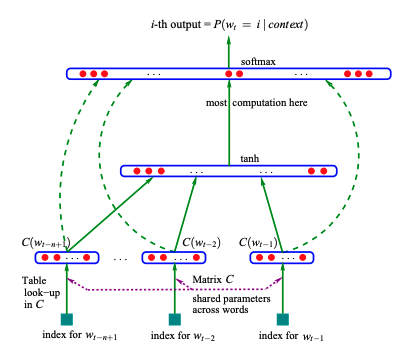

In [3]:
Image('mlp.png')

In [4]:
words = open('data/names.txt', 'r').read().splitlines()

In [5]:
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [6]:
chars = [chr(i) for i in range(ord('a'), ord('z')+1)]
stoi = {s:i+1 for i, s in enumerate(chars)} # map characters to numbers
stoi['.'] = 0 # special character indicating start and end
itos = {i:s for s, i in stoi.items()} # used for visualization

First let's build our dataset, in `X` we have the first three characters we see, and `Y` contains the character after them. 

In [434]:
def build_dataset(words):
    # build the dataset
    block_size = 3
    X, Y = [], []
    
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch] # find index
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
    
            # add the char
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

# split into training and testing sets (explained in part 4)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [435]:
Xtr.shape, Xtr.dtype, Ytr.shape, Ytr.dtype

(torch.Size([182625, 3]), torch.int64, torch.Size([182625]), torch.int64)

## 2. Building the Neural Network

Now the problem is that we have characters that are just labels - 'a', 'b', etc. A neural network can't do maths on labels, hence we have to turn them into numbers. 

An embedding is a lookup table that maps each character to a small vector of floating-point numbers. For example, 'a' might map to `[0.3, -1.2, 0.7]`. Each character gets its own row in the table and those numbers are learned during training.

**Why vector instead of one number**: A single number would impose an arbitrary ordering (is "a" > "b"?). A vector of, say, two or three numbers lets the network place characters in a multidimensional space where similar characters can end up near each other. 

**How it works mechanically**: We have a matrix `C` of shape (vocab_size, embedding_dim). To embed the character at index 3, we just do `C[3]` - a row lookup. This is equivalent to a one-hot vector multiplied by C, but the lookup is far more efficient.

**Note**: The initial example used 5 words and a total of 32 examples (`X` predicts `Y`) from those.

In [436]:
C = torch.randn((27, 2)) # one 2D embedding for each character

We can index into the vector embedding. Think of indexing as replacing every integer with the vector embedding at that row. `C[X]` is going to swap out every integer in `X` with the vector embedding at that row of `C`.

In [439]:
emb = C[Xtr]
emb.shape

torch.Size([182625, 3, 2])

We have 3 context characters, each with a 2D embedding. Before passing them into the hidden layer, we flatten them into a single vector of 6 numbers in order to multiply with the weights.

In [440]:
w1 = torch.randn((6, 100))
b1 = torch.randn(100)

`emb` at this point has shape `(32, 3, 2)` - 32 examples, 3 context characters, 2 dimensional embedding each. 

To transform this into a tensor with shape `(32, 6)`, we need to pull out each character's embedding separately and stacking them side by side. Each of `emb[:, 0, :]`, `emb[:, 1, :]`, `emb[:, 2, :]` will be of shape `(32, 2)`, then we concatenate them by column. 

Interestingly, `torch.unbind()` does exactly this, splitting the tensor along a specific dimension. Calling `unbind()` on `emb` on dimension 1 would give us 3 vectors of shape`(32, 2)`, one for each character, which is exactly what we want. 

In [441]:
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([182625, 6])

There is in fact an even better way to do this. Pytorch has a `view()` function that reshapes the tensor without moving any data in memory. Hence, calling `emb.view(32, 6)` will reinterpret `emb` as a `(32, 6)` tensor, which is equivalent to the `cat`/`unbind` approach but faster and simpler as it's just a reshape. Using -1 as one of the view dimensions tells pytorch to 'figure it out yourself'. 

Now we can build the first hidden layer:

In [442]:
h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
h.shape

torch.Size([182625, 100])

Now the output layer, which wil be of size `(100, 27)` since we have 100 output neurons from the hidden layer and 27 possible characters to choose from:

In [443]:
w2 = torch.randn((100, 27))
b2 = torch.randn(27)

# output layer
logits = h @ w2 + b2

Similar to bigram, we want to apply the softmax function by first exponentiating then normalizing them into probabilities. 

In [444]:
# softmax 
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
prob.shape

torch.Size([182625, 27])

`prob` gives us the probability of the next character after the first 3 characters, for all 32 examples. 

Let's get the probability of the correct character and calculate the negative log-likehood loss.

In [446]:
loss = -prob[torch.arange(prob.shape[0]), Ytr].log().mean()
loss

tensor(15.4758)

In Pytorch, we can actually use `Functional.cross_entropy()` to calculate the negative log-likelihood much more efficiently because pytorch will not create all the intermediary tensors in memory, instead it combines all three into a single fused kernel (a function that runs directly on the hardware), which is faster and uses less memory. 

The problem with three separate operations:
```
Python → kernel 1 (exp)  → back to memory
Python → kernel 2 (sum)  → back to memory  
Python → kernel 3 (log)  → back to memory
```

Each round trip between Python and the kernel, and each write to memory, has overhead. A fused kernel does all three in one trip:
```
Python → kernel (exp + sum + log combined) → back to memory
```
There's also a numerical stability fix. If any logit is very large, `logit.exp()` can overflow to inf. `F.cross_entropy` internally subtracts the max logit before exponentiating.

A summary of all parameters and layers we have defined:

In [447]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g) # 2D embeeding of each character

# weights and biases for each input neuron
w1 = torch.randn((6, 100), generator=g) 
b1 = torch.randn(100, generator=g) 

# weights and biases for each neuron in the hidden layer
w2 = torch.randn((100, 27), generator=g) 
b2 = torch.randn(27, generator=g) 

parameters = [C, w1, b1, w2, b2]
print(f"Total Number of Parameters: {sum(p.nelement() for p in parameters)}")

Total Number of Parameters: 3481


In [448]:
emb = C[X] # turn each integer (32 examples, 3 characters) in the input into a 2D embedding (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ w1 + b1) # first hidden layer
logits = h @ w2 + b2 # output layer 
loss = F.cross_entropy(logits, Y) # calculate loss with softmax + negative log-likelihood

print(f"The loss is: {loss}")

The loss is: 19.505229949951172


## 3. Training the Neural Network

So far every forward pass uses only 5 words (32 examples), but the actual dataset contains 200,000+ words. Computing the loss over all of them before taking a single step is slow. 

Instead of using all examples, we grad a small random subset each step. Each step uses a different random 32 examples. The gradient is noisier than using the full dataset, but it's a good enough estimate. 

Now we can use gradient descent to minimize the loss:

In [449]:
for p in parameters:
    p.requires_grad = True

In [474]:
epoch = 10000
learning_rate = 0.1

for _ in range(epoch):
    ix = torch.randint(0, Xtr.shape[0], (32,)) # pick 32 random indices
    
    # forward pass 
    emb = C[Xtr[ix]] # look up embeddings → (32, 3, 2), using only the subset
    h = torch.tanh(emb.view(-1, 6) @ w1 + b1) # hidden layer → (32, 100)
    logits = h @ w2 + b2 # output layer → (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix]) # single number: how wrong are we
    
    # backward pass
    for p in parameters:
        p.grad = None      # clear old gradients first (they accumulate otherwise)
    loss.backward()        # PyTorch computes gradient for every parameter automatically
    
    # update 
    for p in parameters:
        p.data += -learning_rate * p.grad
    
print(f"Loss: {loss.item():.4f}")

Loss: 2.1754


Another problem is that we don't know what the optimal learning rate is. When the learning rate is too large, each update can overshoot.

A good way to determine the learning rate is by trying a range of values and plotting the loss against them. 

From the plot below, we see that 0.1 is actually a fairly good learning rate. 

In [460]:
lre = torch.linspace(-3, 0, 1000) # exponents, 10^x
lrs = 10**lre # actual learning rates

In [461]:
lri, lossi = [], []

for i in range(1000):
    ix = torch.randint(0, Xtr.shape[0], (32,)) # pick 32 random indices
    
    # forward pass 
    emb = C[Xtr[ix]] # look up embeddings → (32, 3, 2), using only the subset
    h = torch.tanh(emb.view(-1, 6) @ w1 + b1) # hidden layer → (32, 100)
    logits = h @ w2 + b2 # output layer → (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix]) # single number: how wrong are we
    
    # backward pass
    for p in parameters:
        p.grad = None      # clear old gradients first (they accumulate otherwise)
    loss.backward()        # PyTorch computes gradient for every parameter automatically
    
    # update, using each learning rate
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    lri.append(lre[i])
    lossi.append(loss.item())

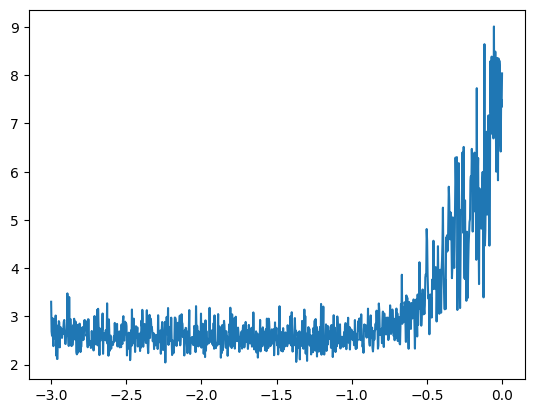

In [462]:
plt.plot(lri, lossi)

## 4. Model Evaluation

If we train on all our data and then measure loss on that same data, the network can just memorize the training examples and get a great loss without actually learning anything useful. This is overfitting, and hence we need a training set (80%), a validation set (10%) and a testing set (10%). Validation set is used to train the hyperparameters.

In [471]:
# model's loss on training set
emb = C[Xtr] 
h = torch.tanh(emb.view(-1, 6) @ w1 + b1) 
logits = h @ w2 + b2 
loss_tr = F.cross_entropy(logits, Ytr) 

# evaluate the model using validation set
emb = C[Xdev] 
h = torch.tanh(emb.view(-1, 6) @ w1 + b1) 
logits = h @ w2 + b2 
loss_dev = F.cross_entropy(logits, Ydev) 

print(f"Training set loss: {loss_tr}\nValidation set loss: {loss_dev}")

Training set loss: 2.531534433364868
Validation set loss: 2.529494285583496


Above we evaluate using the validation set, and we see that the losses are about equal to the training set. This tells us we are not overfitting, but in fact underfitting. Because if the network had enough capacity to learn the data well, training loss would be lower than validation loss. This typically means the current neural network is too small to follow the patterns in the language, hence we need to scale it up. 

A few potential ways to scale this is:
1. **Increase embedding dimension** (currently 2): Each character is squashed into a 2D point. That's very little room to encode meaningful differences between 27 characters. Bumping this up lets the network place characters more distinctly in embedding space.

2. **Hidden layer size** (number of neurons): The hidden layer is what mixes the context characters together and finds patterns. Too few neurons and it can't represent complex combinations.

3. More context characters, more layers, more training steps.

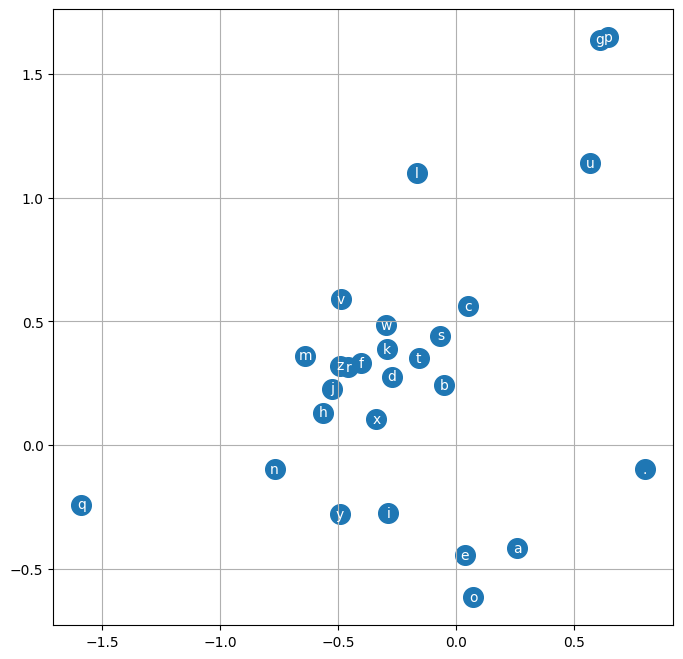

In [491]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

Finally, let's sample some names from the new model to see if there are any improvements from the bigram model: 

In [490]:
for _ in range(10):
    out = []
    context = [0] * block_size

    while True:
        # getting the probabilities
        emb = C[torch.tensor([context])] # embed the current 3 context characters
        h = torch.tanh(emb.view(1, -1) @ w1 + b1) # hidden layer, one row as this is only one example
        logits = h @ w2 + b2 # output layer
        probs = F.softmax(logits, dim=1) # convert to probabilities

        # get the next character
        ix = torch.multinomial(probs, num_samples=1, generator=g).item() # sample randomly from the output probabilities
        context = context[1:] + [ix] # update context
        out.append(ix)

        # stop when we hit end
        if ix == 0:
            break 

    print(''.join(itos[i] for i in out[:-1]))

anasaj
noza
niraen
ademrie
mie
kaya
ali
adridondor
jaden
atiusrah
